In [1]:
from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [3]:
from fem.core.parameters import globalParameters
globalParameters['nDoF'] = 3

from fem.core.Node import Node
from fem.elements.Frame2D import Frame2D
from fem.core.Material import Material
from fem.utils.functions import matrix_extract, matrix_replace

In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [5]:
# Nodes
ft=12

n0 = Node(0, [0, 0], restrain=['r','r','r'])
n1 = Node(1, [6*ft  ,  8*ft], restrain=['f','f','f'] )
n2 = Node(2, [11*ft ,  8*ft], restrain=['f','f','f'], nodal_load=[0,   -20 , 0])
n3 = Node(3, [16*ft ,  8*ft], restrain=['f','f','f'])
n4 = Node(4, [16*ft  ,  0*ft], restrain=['r','r','r'])

all_nodes = [n0, n1, n2, n3, n4]

In [6]:
# Material
steel = Material(name='Steel', E=29000, nu=0.3, rho=7850*0)
# Section
A     = 3
I     = 400

In [7]:
# Elements
e0 = Frame2D(n0, n1, material=steel, A=A, I=I, print_summary=True)
e1 = Frame2D(n1, n2, material=steel, A=A, I=I, print_summary=True)
e2 = Frame2D(n2, n3, material=steel, A=A, I=I, print_summary=True)
e3 = Frame2D(n3, n4, material=steel, A=A, I=I, print_summary=True)

elements = [e0, e1, e2, e3]

----------------------------------------------------------------
Frame2D  :  node 0 → node 1
  Length      : 120.0000 m
  Angle       : 53.1301 deg
  Material    : Steel  (E=2.900e+04, rho=0.0)
  A=3.000e+00 m²   I=4.000e+02 m⁴
  Self-weight : 0.0000 kN/m  |  Applied w: 0.0000 kN/m
  fe (global) : [0. 0. 0. 0. 0. 0.]
  DOF indices : [0 1 2 3 4 5]
  Restraints  : ['r' 'r' 'r' 'f' 'f' 'f']

  kb  (basic stiffness 3×3):
[[   725.          0.          0.    ]
 [     0.     386666.6667 193333.3333]
 [     0.     193333.3333 386666.6667]]

  Tbl (basic←local  3×6):
[[-1.      0.      0.      1.      0.      0.    ]
 [ 0.      0.0083  1.      0.     -0.0083  0.    ]
 [ 0.      0.0083  0.      0.     -0.0083  1.    ]]

  kl  (local stiffness 6×6):
[[   725.          0.          0.       -725.          0.          0.    ]
 [     0.         80.5556   4833.3333      0.        -80.5556   4833.3333]
 [     0.       4833.3333 386666.6667      0.      -4833.3333 193333.3333]
 [  -725.          0.    

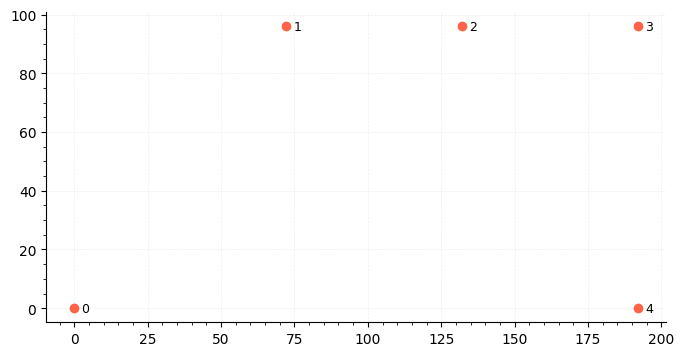

In [8]:
# Nodes
fig, ax = plt.subplots(figsize=(8, 6))
for node in all_nodes:
    node.plotGeometry(ax, text=True)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

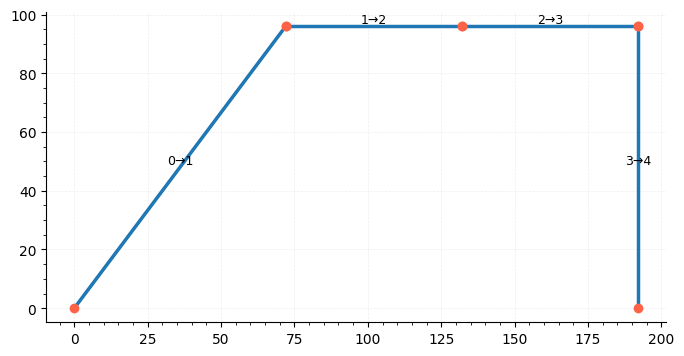

In [9]:
# Model
fig, ax = plt.subplots(figsize=(8, 6))
for elem in elements:
    elem.plot_geometry(ax, show_nodes=True, element_label=True,
                       color='tab:blue', lw=2.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

In [10]:
# DOF classification
dof_flags       = np.concatenate([node.restrain for node in all_nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

print(f"Free DOF indices      : {free_dofs.tolist()}")
print(f"Restrained DOF indices: {restrained_dofs.tolist()}")

Free DOF indices      : [3, 4, 5, 6, 7, 8, 9, 10, 11]
Restrained DOF indices: [0, 1, 2, 12, 13, 14]


In [11]:
n_dof = max(node.idx.max() for node in all_nodes) + 1

# Assembly
K = np.zeros((n_dof, n_dof))
F = np.zeros(n_dof)

for elem in elements:
    K = matrix_replace(K, elem.kg, elem.idx, elem.idx)
    F[elem.idx] += elem.fe              # self-weight + distributed load

for node in all_nodes:
    F[node.idx] += node.nodalLoad       # concentrated nodal loads
    
print('Node Load Map =' , F )

Node Load Map = [  0.   0.   0.   0.   0.   0.   0. -20.   0.   0.   0.   0.   0.   0.   0.]


In [12]:
# Partitioning
dof_flags       = np.concatenate([node.restrain for node in all_nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

Kff = matrix_extract(K, free_dofs,       free_dofs)
Kfr = matrix_extract(K, free_dofs,       restrained_dofs)
Krf = matrix_extract(K, restrained_dofs, free_dofs)
Krr = matrix_extract(K, restrained_dofs, restrained_dofs)

Ff = F[free_dofs]
Fr = F[restrained_dofs]

print("Free nodal forces     :", Ff)
print("Restrained nodal forces:", Fr)

Free nodal forces     : [  0.   0.   0.   0. -20.   0.   0.   0.   0.]
Restrained nodal forces: [0. 0. 0. 0. 0. 0.]


In [13]:
print(Kff)

[[   1762.555556     309.333333    3866.666667   -1450.             0.             0.             0.             0.             0.      ]
 [    309.333333    1137.444444   16433.333333       0.          -644.444444   19333.333333       0.             0.             0.      ]
 [   3866.666667   16433.333333 1160000.             0.        -19333.333333  386666.666667       0.             0.             0.      ]
 [  -1450.             0.             0.          2900.             0.             0.         -1450.             0.             0.      ]
 [      0.          -644.444444  -19333.333333       0.          1288.888889       0.             0.          -644.444444   19333.333333]
 [      0.         19333.333333  386666.666667       0.             0.       1546666.666667       0.        -19333.333333  386666.666667]
 [      0.             0.             0.         -1450.             0.             0.          1607.335069      -0.          7552.083333]
 [      0.             0.         

## Direct Stiffness Method

$$

K_b = 
\begin{bmatrix}
\frac{AE}{L} & 0 & 0 \\
0 & \frac{4EI}{L} & \frac{2EI}{L} \\
0 & \frac{2EI}{L} & \frac{4EI}{L}
\end{bmatrix}
$$

$$
K_a = \sum_{i=1}^{\text{num.Ele.}} 
T_{ga,i}^T T_{lg,i}^T T_{bl,i}^T K_{b,i} T_{bl,i} T_{lg,i} T_{ga,i}
$$

$$
F_a = K_a u_a
$$

$$
\begin{bmatrix}
F_f \\
F_r
\end{bmatrix}
=
\begin{bmatrix}
K_{ff} & K_{fr} \\
K_{rf} & K_{rr}
\end{bmatrix}
\begin{bmatrix}
u_f \\
u_r
\end{bmatrix}
$$

$$
F_f = K_{ff} u_f + K_{fr} u_r
$$

$$
u_f = K_{ff}^{-1} (F_f - K_{fr} u_r)
$$

$$
F_r = K_{rf} u_f + K_{rr} u_r

$$

$$
K = T_{\text{rez}}^T \cdot T_{\text{lg}}^T \cdot T_{\text{bl}}^T \cdot K_b \cdot T_{\text{bl}} \cdot T_{\text{lg}} \cdot T_{\text{rez}}
$$


In [14]:
ur = np.zeros(len(restrained_dofs))

In [15]:
# Solution
uf = np.linalg.solve(Kff, Ff - Kfr @ ur)

u = np.zeros(n_dof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur

In [16]:
# Nodal displacements
for node in all_nodes:
    d = u[node.idx]
    print(f"Node {node.name}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}  theta={d[2]:+.6f}")

Node 0:  ux=+0.000000  uy=+0.000000  theta=+0.000000
Node 1:  ux=+0.021960  uy=-0.033050  theta=-0.000617
Node 2:  ux=+0.017998  uy=-0.055102  theta=+0.000281
Node 3:  ux=+0.014035  uy=-0.013559  theta=+0.000468
Node 4:  ux=+0.000000  uy=+0.000000  theta=+0.000000


In [17]:
# Support reactions
R_full = np.zeros(n_dof)
R_full[restrained_dofs] = Rr
for node in all_nodes:
    if any(r == 'r' for r in node.restrain):
        r = R_full[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}  Rm={r[2]:+.6f}")

Node 0:  Rx=+5.745444  Ry=+7.711810  Rm=+61.481864
Node 4:  Rx=-5.745444  Ry=+12.288190  Rm=+219.185696


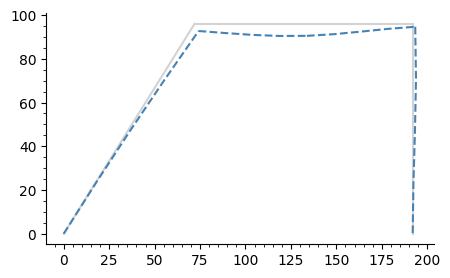

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_geometry(ax, show_nodes=False, color='lightgray', lw=1.5)
for elem in elements:
    elem.plot_deformed(u, scale=100, ax=ax , n_points=5)
plt.show()

In [19]:
# Force recovery
for i, elem in enumerate(elements):
    res = elem.get_results(u)
    fl  = res['fe_local']
    fg  = res['fe_global']
    
    print(f"\nElement {i}  (node {elem.node_i.name} → node {elem.node_j.name})")
    print(f"  Basic  :  N={res['fe_basic'][0]:+.6f}   M_i={res['fe_basic'][1]:+.6f}   M_j={res['fe_basic'][2]:+.6f}")
    print(f"  Local  :  N_i={fl[0]:+.6f}  V_i={fl[1]:+.6f}  M_i={fl[2]:+.6f}  |  N_j={fl[3]:+.6f}  V_j={fl[4]:+.6f}  M_j={fl[5]:+.6f}")
    print(f"  Global :  N_i={fg[0]:+.6f}  V_i={fg[1]:+.6f}  M_i={fg[2]:+.6f}  |  N_j={fg[3]:+.6f}  V_j={fg[4]:+.6f}  M_j={fg[5]:+.6f}")


Element 0  (node 0 → node 1)
  Basic  :  N=-9.616714   M_i=+61.481864   M_j=-57.794131
  Local  :  N_i=+9.616714  V_i=+0.030731  M_i=+61.481864  |  N_j=-9.616714  V_j=-0.030731  M_j=-57.794131
  Global :  N_i=+5.745444  V_i=+7.711810  M_i=+61.481864  |  N_j=-5.745444  V_j=-7.711810  M_j=-57.794131

Element 1  (node 1 → node 2)
  Basic  :  N=-5.745444   M_i=+57.794131   M_j=+404.914482
  Local  :  N_i=+5.745444  V_i=+7.711810  M_i=+57.794131  |  N_j=-5.745444  V_j=-7.711810  M_j=+404.914482
  Global :  N_i=+5.745444  V_i=+7.711810  M_i=+57.794131  |  N_j=-5.745444  V_j=-7.711810  M_j=+404.914482

Element 2  (node 2 → node 3)
  Basic  :  N=-5.745444   M_i=-404.914482   M_j=-332.376906
  Local  :  N_i=+5.745444  V_i=-12.288190  M_i=-404.914482  |  N_j=-5.745444  V_j=+12.288190  M_j=-332.376906
  Global :  N_i=+5.745444  V_i=-12.288190  M_i=-404.914482  |  N_j=-5.745444  V_j=+12.288190  M_j=-332.376906

Element 3  (node 3 → node 4)
  Basic  :  N=-12.288190   M_i=+332.376906   M_j=+219.185

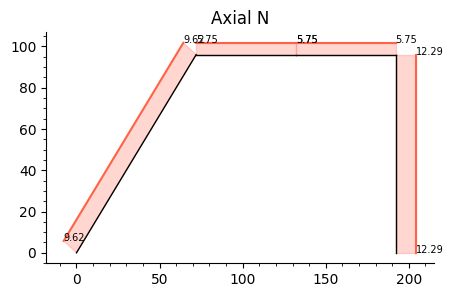

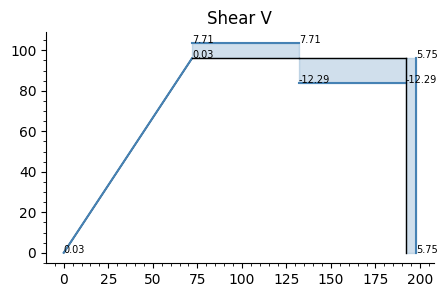

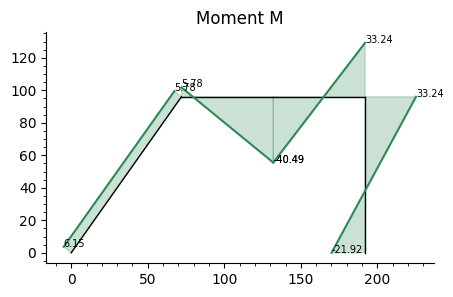

In [20]:
fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_axial(u, ax=ax, scale=-1, n_points=5)
ax.set_title("Axial N")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_shear(u, ax=ax, scale=1, n_points=5)
ax.set_title("Shear V")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_moment(u, ax=ax, scale=-0.1, n_points=5)
ax.set_title("Moment M")
plt.show()

## Opensees

In [21]:
import openseespy.opensees as ops
# import opensees as ops
import opsvis as opsplt

ops.wipe()
ops.model('Basic', '-ndm', 2, '-ndf', 3)

In [22]:
# Nodes 
for node in all_nodes:
    ops.node(node.name, *node.coordinates)

In [23]:
# Restraints
for node in all_nodes:
    ops.fix(node.name, *[1 if r == 'r' else 0 for r in node.restrain])

In [ ]:
coordTransf = "Linear"  
ops.geomTransf(coordTransf, 1 , '-jntOffset', 0,   0,    0,   0)

In [25]:
for i, elem in enumerate(elements):
    ops.element('elasticBeamColumn', i,
                elem.node_i.name, elem.node_j.name,
                elem.A, elem.E, elem.I, 1)

<Axes: >

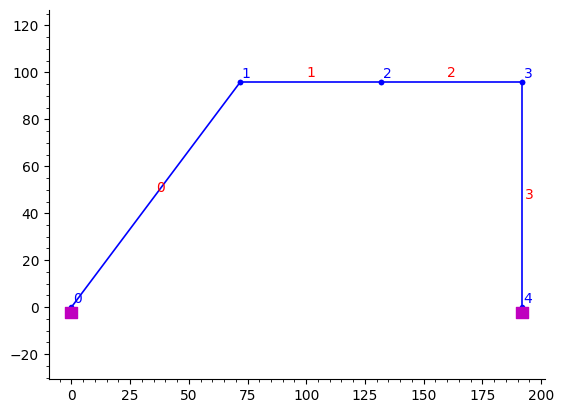

In [26]:
opsplt.plot_model("nodes")

In [27]:
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)

# Nodal loads
for node in all_nodes:
    if any(node.nodalLoad != 0):
        ops.load(node.name, *[float(f) for f in node.nodalLoad])

# Element self-weight
for i, elem in enumerate(elements):
    c = np.cos(elem.angle)
    s = np.sin(elem.angle)
    if abs(s) <= 1e-9:  # horizontal element — transverse load
        ops.eleLoad('-ele', i, '-type', '-beamUniform', float(-elem.w_self), 0.0)
    else:               # vertical or inclined — axial load
        ops.eleLoad('-ele', i, '-type', '-beamUniform', 0.0, float(-elem.w_self))

In [28]:
ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", 1.0)
ops.algorithm("Newton")
ops.analysis("Static")
ops.analyze(1)
ops.reactions()

In [29]:
Kfree=ops.printA()
print(Kfree)

None



1762.56 309.333 3866.67 -1450 0 0 0 0 0 
309.333 1137.44 16433.3 0 -644.444 19333.3 0 0 0 
3866.67 16433.3 1.16e+06 0 -19333.3 386667 0 0 0 
-1450 0 0 2900 0 0 -1450 0 0 
0 -644.444 -19333.3 0 1288.89 0 0 -644.444 19333.3 
0 19333.3 386667 0 0 1.54667e+06 0 -19333.3 386667 
0 0 0 -1450 0 0 1607.34 0 7552.08 
0 0 0 0 -644.444 -19333.3 0 1550.69 -19333.3 
0 0 0 0 19333.3 386667 7552.08 -19333.3 1.25667e+06 



In [30]:
# Nodal displacements
for node in all_nodes:
    d = ops.nodeDisp(node.name)
    print(f"Node {node.name}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}  theta={d[2]:+.6f}")

Node 0:  ux=+0.000000  uy=+0.000000  theta=+0.000000
Node 1:  ux=+0.021960  uy=-0.033050  theta=-0.000617
Node 2:  ux=+0.017998  uy=-0.055102  theta=+0.000281
Node 3:  ux=+0.014035  uy=-0.013559  theta=+0.000468
Node 4:  ux=+0.000000  uy=+0.000000  theta=+0.000000


In [31]:
# Reactions
ops.reactions()
for node in all_nodes:
    if any(r == 'r' for r in node.restrain):
        rx = ops.nodeReaction(node.name, 1)
        ry = ops.nodeReaction(node.name, 2)
        rm = ops.nodeReaction(node.name, 3)
        print(f"Node {node.name}:  Rx={rx:+.4f}  Ry={ry:+.4f}  Rm={rm:+.4f}")

Node 0:  Rx=+5.7454  Ry=+7.7118  Rm=+61.4819
Node 4:  Rx=-5.7454  Ry=+12.2882  Rm=+219.1857


Text(0.5, 1.0, 'Deformed Structure')

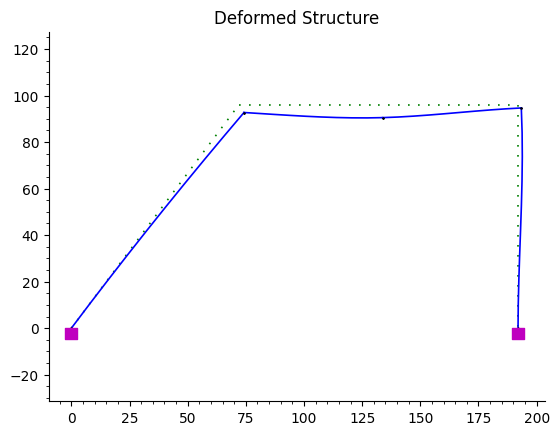

In [32]:
opsplt.plot_defo(100 , 
                 10, 
                 az_el=None, 
                 fig_wi_he=None, 
                 endDispFlag=0)

plt.title('Deformed Structure')

In [33]:
# Element forces
for i, elem in enumerate(elements):
    fl = ops.eleResponse(i, 'localForce')
    fg = ops.eleResponse(i, 'globalForce')
    print(f"\nElement {i}  (node {elem.node_i.name} → node {elem.node_j.name})")
    print(f"  Local  :  N_i={fl[0]:+.6f}  V_i={fl[1]:+.6f}  M_i={fl[2]:+.6f}  |  N_j={fl[3]:+.6f}  V_j={fl[4]:+.6f}  M_j={fl[5]:+.6f}")
    print(f"  Global :  N_i={fg[0]:+.6f}  V_i={fg[1]:+.6f}  M_i={fg[2]:+.6f}  |  N_j={fg[3]:+.6f}  V_j={fg[4]:+.6f}  M_j={fg[5]:+.6f}")


Element 0  (node 0 → node 1)
  Local  :  N_i=+9.616714  V_i=+0.030731  M_i=+61.481864  |  N_j=-9.616714  V_j=-0.030731  M_j=-57.794131
  Global :  N_i=+5.745444  V_i=+7.711810  M_i=+61.481864  |  N_j=-5.745444  V_j=-7.711810  M_j=-57.794131

Element 1  (node 1 → node 2)
  Local  :  N_i=+5.745444  V_i=+7.711810  M_i=+57.794131  |  N_j=-5.745444  V_j=-7.711810  M_j=+404.914482
  Global :  N_i=+5.745444  V_i=+7.711810  M_i=+57.794131  |  N_j=-5.745444  V_j=-7.711810  M_j=+404.914482

Element 2  (node 2 → node 3)
  Local  :  N_i=+5.745444  V_i=-12.288190  M_i=-404.914482  |  N_j=-5.745444  V_j=+12.288190  M_j=-332.376906
  Global :  N_i=+5.745444  V_i=-12.288190  M_i=-404.914482  |  N_j=-5.745444  V_j=+12.288190  M_j=-332.376906

Element 3  (node 3 → node 4)
  Local  :  N_i=+12.288190  V_i=+5.745444  M_i=+332.376906  |  N_j=-12.288190  V_j=-5.745444  M_j=+219.185696
  Global :  N_i=+5.745444  V_i=-12.288190  M_i=+332.376906  |  N_j=-5.745444  V_j=+12.288190  M_j=+219.185696


Text(0.5, 1.0, 'M')

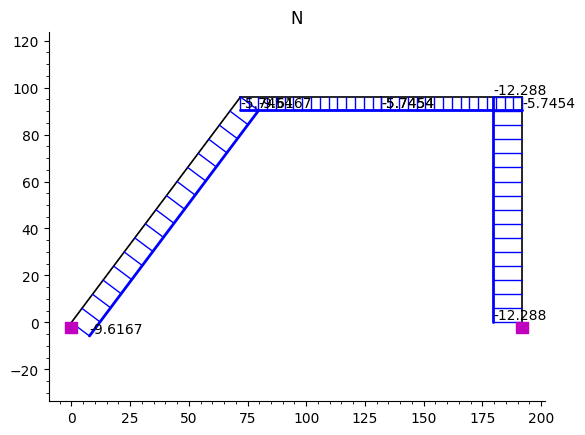

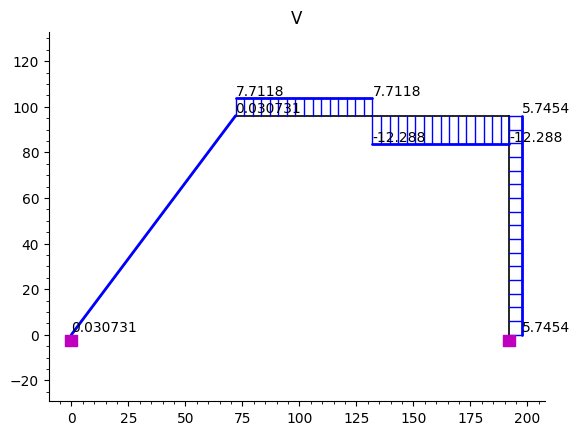

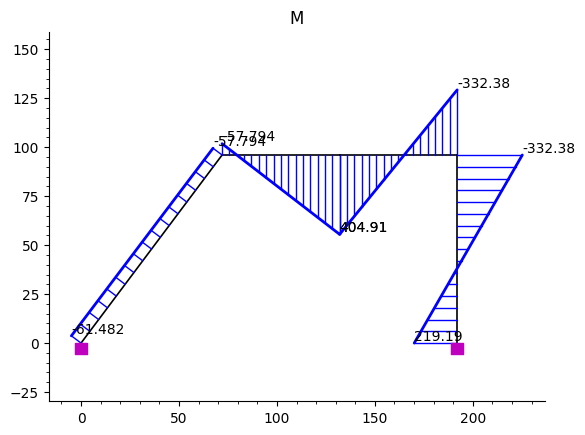

In [34]:
sfac = 1

opsplt.section_force_diagram_2d('N', sfac)
plt.title('N')

opsplt.section_force_diagram_2d('V', sfac)
plt.title('V')

opsplt.section_force_diagram_2d('M', 0.1)
plt.title('M')